#STEP 1: Import Libraries New Section

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#STEP 2: Load Your Datas

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/SHE-code/Electric_Vehicle_Population_Data.csv")
df

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4BZ0CP5G,King,Seattle,WA,98125.0,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,46.0,349455557,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
1,KNDJX3AEXG,King,Renton,WA,98058.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,11.0,210641315,POINT (-122.08747 47.4466),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
2,5YJ3E1EB2J,King,Seattle,WA,98115.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,43.0,171417494,POINT (-122.31676 47.68156),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
3,1C4RJXN64R,Kitsap,Bremerton,WA,98312.0,2024,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,26.0,262542927,POINT (-122.65223 47.57192),PUGET SOUND ENERGY INC,5.303508e+10
4,5YJ3E1EB1J,Thurston,Olympia,WA,98512.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,35.0,110432815,POINT (-122.9131 47.01359),PUGET SOUND ENERGY INC,5.306701e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247339,7G2CEHED0R,King,Newcastle,WA,98056.0,2024,TESLA,CYBERTRUCK,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,41.0,278417947,POINT (-122.1805 47.50006),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
247340,1C4RJYC65R,Pierce,Puyallup,WA,98374.0,2024,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,0.0,25.0,271451197,POINT (-122.27575 47.13959),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
247341,7SAYGDEE0P,King,Bothell,WA,98011.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,1.0,249563667,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
247342,KNDPYDAH9P,Kitsap,Bainbridge Island,WA,98110.0,2023,KIA,SPORTAGE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,34.0,0.0,23.0,238968376,POINT (-122.521 47.62728),PUGET SOUND ENERGY INC,5.303509e+10


#STEP 3: Prepare Your Data

In [ ]:
# Count number of vehicles per year
yearly_data = df.groupby("Model Year").size().reset_index(name="EV_Count")

# Remove invalid years (optional but recommended)
yearly_data = yearly_data[yearly_data["Model Year"] > 2000]

#STEP 4: Define X and y

In [ ]:
X = yearly_data[["Model Year"]]   # independent variable
y = yearly_data["EV_Count"]       # dependent variable

#STEP 5: Train the Model

In [ ]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

#STEP 6: Predict Future Values (Up to 2030)

In [ ]:
future_years = pd.DataFrame({"Model Year": np.arange(2025, 2031)})

predictions = model.predict(future_years)
future_years["Predicted_EV_Count"] = predictions

print(future_years)

   Model Year  Predicted_EV_Count
0        2025        26275.636444
1        2026        27812.524449
2        2027        29349.412454
3        2028        30886.300459
4        2029        32423.188463
5        2030        33960.076468


#STEP 7: Visualize (VERY IMPORTANT for presentation)

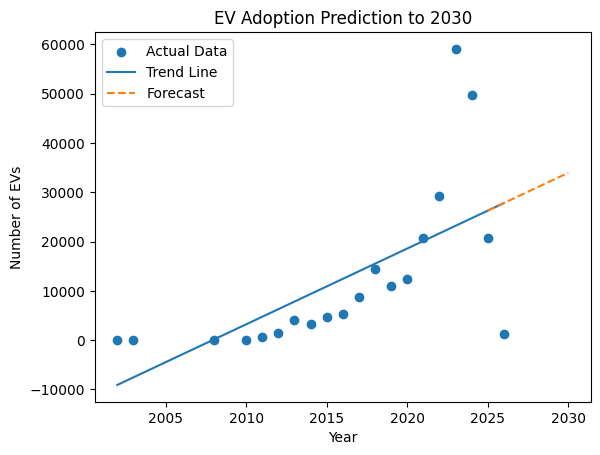

In [ ]:
plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), label="Trend Line")
plt.plot(future_years["Model Year"], predictions, linestyle='dashed', label="Forecast")

plt.xlabel("Year")
plt.ylabel("Number of EVs")
plt.title("EV Adoption Prediction to 2030")
plt.legend()

plt.show()

In [ ]:
print(future_years)



   Model Year  Predicted_EV_Count
0        2025        26275.636444
1        2026        27812.524449
2        2027        29349.412454
3        2028        30886.300459
4        2029        32423.188463
5        2030        33960.076468
